In [1]:
import h5py
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
from neuralop.models import FNO

# from hypermagnetics import plots
# from hypermagnetics.sources import read_db, configure
qt = False

In [2]:
def fno_input_converter(
    sources: np.ndarray,
    shape: str = "sphere",
    dim: int = 2,
    lim: int = 3,
    res: int = 32,
):
    """Convert source parameters to FNO input format."""
    m, r0, size = np.split(sources, 3, axis=-1)
    n_sources, _ = r0.shape
    
    grid_x = np.linspace(-lim, lim, res)
    grid_y = np.linspace(-lim, lim, res)
    if dim > 2:
        grid_z = np.linspace(-lim, lim, res)
        grids = np.meshgrid(grid_x, grid_y, grid_z, indexing="xy")
    else:
        grids = np.meshgrid(grid_x, grid_y, indexing="xy")

    grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
    input_data = np.zeros((res**dim, dim))

    for n in range(n_sources):
        if shape == "sphere":
            idx_in = np.where(
                np.linalg.norm(grid - r0[n], axis=1) <= size[n, 0]
            )[0]
        elif shape == "prism":
            idx_in = np.where(
                (np.abs(grid[:, 0] - r0[n, 0]) <= size[n, 0])
                & (np.abs(grid[:, 1] - r0[n, 1]) <= size[n, 1])
            )[0]
        else:
            raise ValueError("Unknown shape")

        input_data[idx_in] += m[n, :dim]

    return input_data

(16384, 2)
(9,)


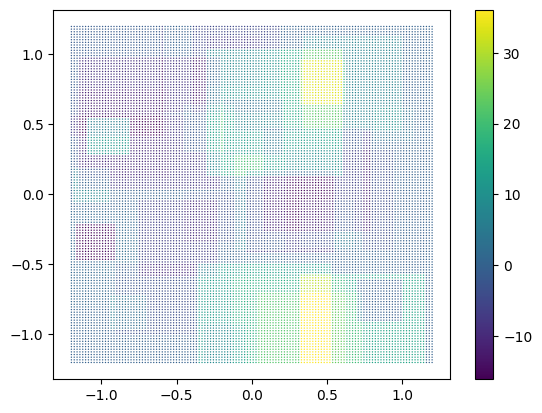

In [3]:
datapath = Path("/home/spol/repos/hypermagnetics/data")
if qt:
    sources = np.load(datapath / "sources_qt_0_1.npy")
    t_msp = np.load(datapath / "gt_msp_grid_qt_0_1.npy")
else:
    sources = np.load(datapath / "sources_1_1.npy")
    t_msp = np.load(datapath / "gt_msp_grid_1_1.npy")

res = 128
batch = 200
res_out = 128 // 4
lim = 1.2
idx = 1

# Check fno function
input = fno_input_converter(sources, shape="prism", res=res, lim=1.2)
print(input.shape)
grids = np.meshgrid(
            np.linspace(-lim, lim, res),
            np.linspace(-lim, lim, res),
            np.linspace(0, 0, 1),
        )
grid = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid = np.array(grid[:, 0].reshape((res, res)))
y_grid = np.array(grid[:, 1].reshape((res, res)))

# Plot example
print(sources[idx].shape)
contour = plt.scatter(x_grid, y_grid, c=input[..., 0].reshape((res, res)), cmap='viridis', s=1, edgecolors='none')
plt.colorbar(contour)

In [4]:
modelpath = Path("/home/spol/repos/hypermagnetics/models/fno")
modelname = "fno_large_m_128_1M"
model = FNO.from_checkpoint(save_folder=modelpath, save_name=modelname)

input = torch.from_numpy((
    np.array(input[None, :])
    .reshape(1, res, res, -1)
    .transpose(0, 3, 1, 2)).astype(np.float32)
)
out = model(input).to("cpu").detach().numpy()
print(out.shape)

(1, 1, 32, 32)


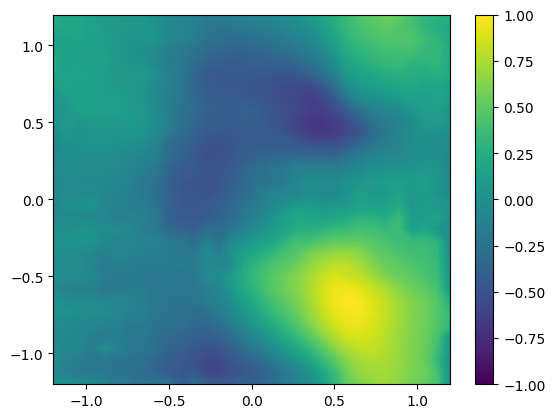

In [5]:
grids = np.meshgrid(
            np.linspace(-lim, lim, res_out),
            np.linspace(-lim, lim, res_out),
            np.linspace(0, 0, 1),
        )
grid_out = np.concatenate([g.ravel()[:, None] for g in grids], axis=-1)
x_grid_out = np.array(grid_out[:, 0].reshape((res_out, res_out)))
y_grid_out = np.array(grid_out[:, 1].reshape((res_out, res_out)))

if qt:
    vmax = 4.5 / 10
else:
    vmax = 10 / 10
cbar_ticks = np.linspace(-vmax, vmax, 9)

norm = mcolors.Normalize(vmin=-vmax, vmax=vmax)
levels = np.linspace(-vmax, vmax, 250)  # evenly spaced, symmetric levels
contour = plt.contourf(x_grid_out, y_grid_out, np.clip(out[0,0] / 10, -vmax, vmax), levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)

(32, 32)


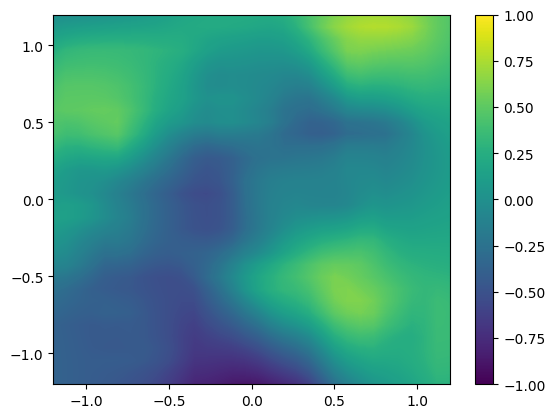

In [6]:
print(t_msp.shape)
contour = plt.contourf(x_grid_out, y_grid_out, np.clip(t_msp / 10, -vmax, vmax), levels=levels, cmap='viridis', norm=norm)
cbar = plt.colorbar(contour)
cbar.set_ticks(cbar_ticks)